# House Price Prediction using Machine Learning
This project predicts residential property prices using multiple regression algorithms. The workflow includes data cleaning, exploratory data analysis (EDA), feature engineering, preprocessing, model comparison, hyperparameter tuning using GridSearchCV, and final prediction generation.

## Data Cleaning

The dataset was inspected for missing values, duplicates, outliers, and inconsistent records.
Several suspicious observations were identified during exploratory analysis. However, rows in the **test dataset were not removed**, even if they appeared unusual. Since the test set represents unseen data used for final prediction, removing rows would change the number of required predictions and result in an invalid submission.
Only the training dataset was considered for cleaning and analysis, while the test dataset underwent the same preprocessing and feature engineering steps without dropping any observations.

## Dataset

Dataset Source:

https://www.kaggle.com/datasets/anmolkumar/house-price-prediction-challenge/data

The dataset contains residential property information such as:

- Square Footage
- BHK
- Builder Information
- Address
- Latitude
- Longitude
- Construction Status

Target Variable:
TARGET(PRICE_IN_LACS)

In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt

In [6]:
import seaborn as sns

In [7]:
train=pd.read_csv("train.csv")

In [8]:
test=pd.read_csv("test.csv")

In [9]:
train.shape

(29451, 12)

In [10]:
test.shape

(68720, 11)

In [11]:
train.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


In [12]:
test.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE
0,Owner,0,0,1,BHK,545.171340,1,1,"Kamrej,Surat",21.262000,73.047700
1,Dealer,1,1,2,BHK,800.000000,0,0,"Panvel,Lalitpur",18.966114,73.148278
2,Dealer,0,0,2,BHK,1257.096513,1,1,"New Town,Kolkata",22.592200,88.484911
3,Dealer,0,0,3,BHK,1400.329489,1,1,"Kalwar Road,Jaipur",26.988300,75.584600
4,Owner,0,0,1,BHK,430.477830,1,1,"Mai Mandir,Nadiad",22.700000,72.870000


In [13]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29451 entries, 0 to 29450
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   POSTED_BY              29451 non-null  object 
 1   UNDER_CONSTRUCTION     29451 non-null  int64  
 2   RERA                   29451 non-null  int64  
 3   BHK_NO.                29451 non-null  int64  
 4   BHK_OR_RK              29451 non-null  object 
 5   SQUARE_FT              29451 non-null  float64
 6   READY_TO_MOVE          29451 non-null  int64  
 7   RESALE                 29451 non-null  int64  
 8   ADDRESS                29451 non-null  object 
 9   LONGITUDE              29451 non-null  float64
 10  LATITUDE               29451 non-null  float64
 11  TARGET(PRICE_IN_LACS)  29451 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 2.7+ MB


In [14]:
train.describe()

,UNDER_CONSTRUCTION,RERA,BHK_NO.,SQUARE_FT,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
count,29451.000000,29451.000000,29451.000000,2.945100e+04,29451.000000,29451.000000,29451.000000,29451.000000,29451.000000
mean,0.179756,0.317918,2.392279,1.980217e+04,0.820244,0.929578,21.300255,76.837695,142.898746
std,0.383991,0.465675,0.879091,1.901335e+06,0.383991,0.255861,6.205306,10.557747,656.880713
min,0.000000,0.000000,1.000000,3.000000e+00,0.000000,0.000000,-37.713008,-121.761248,0.250000
25%,0.000000,0.000000,2.000000,9.000211e+02,1.000000,1.000000,18.452663,73.798100,38.000000
50%,0.000000,0.000000,2.000000,1.175057e+03,1.000000,1.000000,20.750000,77.324137,62.000000
75%,0.000000,1.000000,3.000000,1.550688e+03,1.000000,1.000000,26.900926,77.828740,100.000000
max,1.000000,1.000000,20.000000,2.545455e+08,1.000000,1.000000,59.912884,152.962676,30000.000000


## Distribution Analysis

Analyze the distribution of numerical features and identify highly skewed variables that may require transformation.

In [15]:
train.skew(numeric_only=True)

UNDER_CONSTRUCTION         1.668090
RERA                       0.782066
BHK_NO.                    2.390076
SQUARE_FT                116.609449
READY_TO_MOVE             -1.668090
RESALE                    -3.358125
LONGITUDE                  0.176655
LATITUDE                 -10.324164
TARGET(PRICE_IN_LACS)     17.583332
dtype: float64

## Feature Exploration
Inspect each feature individually to understand unique values, categorical distributions, and possible data quality issues.

In [16]:
for col in train.columns:
    print(f"column:{col}\n")
    print(train[col].value_counts())
    print("-"*50)

column:POSTED_BY

POSTED_BY
Dealer     18291
Owner      10538
Builder      622
Name: count, dtype: int64
--------------------------------------------------
column:UNDER_CONSTRUCTION

UNDER_CONSTRUCTION
0    24157
1     5294
Name: count, dtype: int64
--------------------------------------------------
column:RERA

RERA
0    20088
1     9363
Name: count, dtype: int64
--------------------------------------------------
column:BHK_NO.

BHK_NO.
2     13324
3     10546
1      3574
4      1723
5       190
6        52
7        11
8        10
20        4
10        4
15        4
12        3
9         3
13        1
17        1
11        1
Name: count, dtype: int64
--------------------------------------------------
column:BHK_OR_RK

BHK_OR_RK
BHK    29427
RK        24
Name: count, dtype: int64
--------------------------------------------------
column:SQUARE_FT

SQUARE_FT
1000.000000    479
1250.000000    294
800.000000     202
1200.000000    179
1600.000000    125
              ... 
1685.097420     

In [17]:
train.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


Cleaning the dataset by handling inconsistent values, removing unnecessary information, and preparing the data for feature engineering.
Starting with "SQUARE_FT"

In [18]:
train["SQUARE_FT"].skew()

np.float64(116.60944946022533)

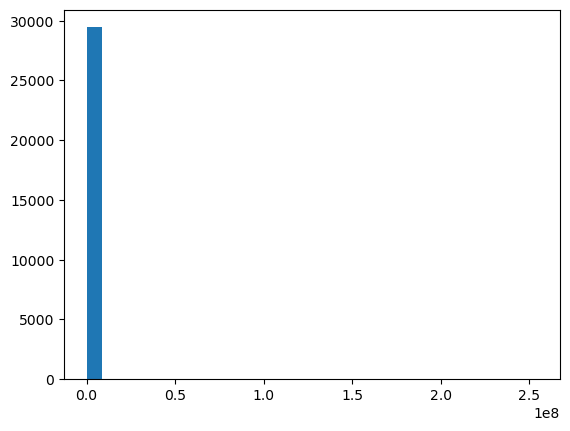

In [19]:
plt.hist(train["SQUARE_FT"],bins=30)
plt.show()

In [20]:
train["SQUARE_FT"].head()

0    1300.236407
1    1275.000000
2     933.159722
3     929.921143
4     999.009247
Name: SQUARE_FT, dtype: float64

In [21]:
train["SQUARE_FT"].tail()

29446    2500.000000
29447     769.230769
29448    1022.641509
29449     927.079009
29450     896.774194
Name: SQUARE_FT, dtype: float64

In [22]:
train["SQUARE_FT"].sample()

9540    624.024961
Name: SQUARE_FT, dtype: float64

In [23]:
train[train["SQUARE_FT"]>100000].shape

(72, 12)

In [24]:
train.nlargest(10,"SQUARE_FT")[["SQUARE_FT","TARGET(PRICE_IN_LACS)","ADDRESS"]]

,SQUARE_FT,TARGET(PRICE_IN_LACS),ADDRESS
10745,2.545455e+08,28000.0,"Malur,Bangalore"
11238,1.875000e+08,30000.0,"R.T. Nagar,Bangalore"
15724,8.064516e+07,25000.0,"Lakkasandra,Bangalore"
25241,4.300000e+06,43.0,"New Kumaran Nagar,Chennai"
28591,8.750000e+05,35.0,"Ajit Singh Nagar,Vijayawada"
15598,7.928571e+05,55.5,"Sainik Colony,Jammu"
373,4.333333e+05,65.0,"Mulanthuruthy,Kochi"
22155,3.400000e+05,17.0,"Sayajipura,Vadodara"
19047,2.460088e+05,9523.0,"Gomti Nagar Extension,Lucknow"
13035,2.425000e+05,9700.0,"Bariatu,Ranchi"


In [25]:
train.nsmallest((10),"SQUARE_FT")[["SQUARE_FT","TARGET(PRICE_IN_LACS)","ADDRESS"]]

,SQUARE_FT,TARGET(PRICE_IN_LACS),ADDRESS
3269,3.000000,12.0,"industrial area,Hajipur"
13763,3.985594,24.9,"Amlidih,Raipur"
2092,5.000000,45.0,"Sector-29 Chandigarh,Chandigarh"
24528,9.397110,32.5,"Brajanathchak,Haldia"
26485,10.000000,8.0,"Punagam,Surat"
15152,10.979906,27.3,"Ganesh Colony,Jalgaon"
20521,31.780067,16.6,"Parthala Khanjarpur,Noida"
15435,32.000000,13.0,"Makanpur,Ghaziabad"
24572,32.000000,16.0,"Sector-118 Noida,Noida"
23849,37.680696,16.5,"Munnu Khera,Lucknow"


In [26]:
train["SQUARE_FT"].quantile([0.01,0.05,0.99,0.999])

0.010       375.000000
0.050       550.000000
0.990      5462.568609
0.999    154221.755330
Name: SQUARE_FT, dtype: float64

In [27]:
train[train["SQUARE_FT"]<200][["SQUARE_FT","TARGET(PRICE_IN_LACS)","ADDRESS"]].sort_values("SQUARE_FT")

,SQUARE_FT,TARGET(PRICE_IN_LACS),ADDRESS
3269,3.000000,12.0,"industrial area,Hajipur"
13763,3.985594,24.9,"Amlidih,Raipur"
2092,5.000000,45.0,"Sector-29 Chandigarh,Chandigarh"
24528,9.397110,32.5,"Brajanathchak,Haldia"
26485,10.000000,8.0,"Punagam,Surat"
15152,10.979906,27.3,"Ganesh Colony,Jalgaon"
20521,31.780067,16.6,"Parthala Khanjarpur,Noida"
24572,32.000000,16.0,"Sector-118 Noida,Noida"
15435,32.000000,13.0,"Makanpur,Ghaziabad"
23849,37.680696,16.5,"Munnu Khera,Lucknow"


In [28]:
train[train["SQUARE_FT"]<200].shape

(40, 12)

In [29]:
thresh_largest=train["SQUARE_FT"].quantile(0.999)

In [30]:
thresh_smallest=train["SQUARE_FT"].quantile(0.00136)

In [31]:
train=train[train["SQUARE_FT"]<=thresh_largest]

In [32]:
train=train[train["SQUARE_FT"]>=thresh_smallest]

In [33]:
train.shape

(29380, 12)

In [34]:
train.nsmallest((10),"SQUARE_FT")[["SQUARE_FT","TARGET(PRICE_IN_LACS)","BHK_NO.","BHK_OR_RK","ADDRESS"]]

,SQUARE_FT,TARGET(PRICE_IN_LACS),BHK_NO.,BHK_OR_RK,ADDRESS
14774,202.836663,39.9,1,RK,"Bhandup (West),Lalitpur"
27879,204.510281,37.0,3,BHK,"Sector-9 Malviya Nagar,Jaipur"
24912,215.285253,14.0,1,BHK,"Nyay Khand 1,Ghaziabad"
27338,217.778658,11.0,1,BHK,"Bharathi Nagar,Coimbatore"
25959,219.014937,21.7,1,BHK,"Fatherwadi Vasai East,Palghar"
15110,220.001491,59.0,1,RK,"Eksar,Lalitpur"
20303,220.005867,15.0,1,BHK,"Shastri Nagar,Pune"
16140,220.013038,27.0,2,BHK,"Niti Khand 2,Ghaziabad"
16559,221.653879,10.4,1,RK,"Nandore,Lalitpur"
10351,224.971879,8.0,1,BHK,"Madhuban Bapudham,Ghaziabad"


In [35]:
train.nlargest(10,"SQUARE_FT")[["SQUARE_FT","TARGET(PRICE_IN_LACS)","BHK_NO.","BHK_OR_RK","ADDRESS"]]

,SQUARE_FT,TARGET(PRICE_IN_LACS),BHK_NO.,BHK_OR_RK,ADDRESS
13677,153949.5798,9160.0,3,BHK,"Sector-79 Noida,Noida"
17261,153493.2957,8700.0,3,BHK,"Sector-90 Gurgaon,Gurgaon"
2917,150232.5581,6460.0,3,BHK,"Navalur,Chennai"
19995,149969.0785,9700.0,3,BHK,"Kogilu,Bangalore"
5799,148939.7228,8920.0,3,BHK,"Whitefield,Bangalore"
12018,148828.8288,8260.0,3,BHK,"Sahakara Nagar,Bangalore"
9454,147913.1886,8860.0,3,BHK,"Porur,Chennai"
1225,147428.5714,5160.0,3,BHK,"New Chandigarh,Chandigarh"
8167,147384.6154,9580.0,2,BHK,"Sector-70A Gurgaon,Gurgaon"
8114,145892.8571,8170.0,3,BHK,"Jakkur,Bangalore"


In [36]:
train[train["BHK_NO."]>8][["SQUARE_FT","TARGET(PRICE_IN_LACS)","BHK_NO.","BHK_OR_RK","ADDRESS"]]

,SQUARE_FT,TARGET(PRICE_IN_LACS),BHK_NO.,BHK_OR_RK,ADDRESS
2215,6373.486297,200.00,12,BHK,"Ashok Nagar , Kalapatti, Coimbatore District,C..."
3466,348.863897,15.20,20,BHK,"Rat,Ratnagiri"
3882,42500.000000,0.85,10,BHK,"Dharga,Hosur"
6963,1313.580968,180.00,9,BHK,"T Dasarahalli,Bangalore"
8872,10460.251050,500.00,13,BHK,"Bagalur,Bangalore"
13440,11000.343760,320.00,17,BHK,"Karanodai,Chennai"
13993,4356.740133,85.00,10,BHK,"Kuansh,Bhadrak"
15026,5866.666667,220.00,9,BHK,"Durgapura,Jaipur"
16278,3000.107147,280.00,15,BHK,"Jharapada,Bhubaneswar"
16397,4000.000000,55.00,11,BHK,"Jaipur road,Bikaner"


In [37]:
train=train.drop(index=3466)

In [38]:
train.shape

(29379, 12)

In [39]:
train.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


In [40]:
train.skew(numeric_only=True)

UNDER_CONSTRUCTION        1.670213
RERA                      0.781411
BHK_NO.                   2.171960
SQUARE_FT                18.432489
READY_TO_MOVE            -1.670213
RESALE                   -3.375427
LONGITUDE                 0.178609
LATITUDE                -10.315383
TARGET(PRICE_IN_LACS)    14.264715
dtype: float64

In [41]:
train.nsmallest(10,"LATITUDE")[["LONGITUDE","LATITUDE","ADDRESS"]]

,LONGITUDE,LATITUDE,ADDRESS
19452,37.294173,-121.761248,"Near silver Estate,Latma road, Singhmore,Ranchi"
770,58.691753,-117.001699,"AB Bypass Road,Indore"
8322,58.691753,-117.001699,"AB Bypass Road,Indore"
11729,58.691753,-117.001699,"AB Bypass Road,Indore"
17578,58.691753,-117.001699,"AB Bypass Road,Indore"
18297,58.691753,-117.001699,"AB Bypass Road,Indore"
25607,58.691753,-117.001699,"AB Bypass Road,Indore"
2663,46.909674,-114.053121,"Sector 132 Expressway,Noida"
10567,40.016847,-105.279193,"Green Earth City ,Patan Road,Raipur,Raipur"
2693,42.049481,-87.681841,"Parel,Mumbai"


In [42]:
train.nlargest(10,"LATITUDE")[["LONGITUDE","LATITUDE","ADDRESS"]]

,LONGITUDE,LATITUDE,ADDRESS
27723,-27.550328,152.962676,"100 Feet Road,Anand"
20630,-37.713008,144.957843,"Brooke Bond First Cross,Bangalore"
21200,-37.713008,144.957843,"Brooke Bond First Cross,Bangalore"
23805,-37.713008,144.957843,"Brooke Bond First Cross,Bangalore"
15722,35.578524,139.554449,"3rd Phase JP Nagar,Bangalore"
568,35.000000,136.000000,"7th Phase JP Nagar,Bangalore"
625,35.000000,136.000000,"6th Phase JP Nagar,Bangalore"
1752,35.000000,136.000000,"7th Phase JP Nagar,Bangalore"
2872,35.000000,136.000000,"6th Phase JP Nagar,Bangalore"
3219,35.000000,136.000000,"7th Phase JP Nagar,Bangalore"


In [43]:
train.duplicated().sum()

np.int64(400)

In [44]:
train=train.drop_duplicates()

In [45]:
train.shape

(28979, 12)

In [46]:
train.nsmallest(10,"LATITUDE")[["LONGITUDE","LATITUDE","ADDRESS"]]

,LONGITUDE,LATITUDE,ADDRESS
19452,37.294173,-121.761248,"Near silver Estate,Latma road, Singhmore,Ranchi"
770,58.691753,-117.001699,"AB Bypass Road,Indore"
8322,58.691753,-117.001699,"AB Bypass Road,Indore"
11729,58.691753,-117.001699,"AB Bypass Road,Indore"
17578,58.691753,-117.001699,"AB Bypass Road,Indore"
18297,58.691753,-117.001699,"AB Bypass Road,Indore"
25607,58.691753,-117.001699,"AB Bypass Road,Indore"
2663,46.909674,-114.053121,"Sector 132 Expressway,Noida"
10567,40.016847,-105.279193,"Green Earth City ,Patan Road,Raipur,Raipur"
2693,42.049481,-87.681841,"Parel,Mumbai"


In [47]:
train.nlargest(10,"LATITUDE")[["LONGITUDE","LATITUDE","ADDRESS"]]

,LONGITUDE,LATITUDE,ADDRESS
27723,-27.550328,152.962676,"100 Feet Road,Anand"
20630,-37.713008,144.957843,"Brooke Bond First Cross,Bangalore"
21200,-37.713008,144.957843,"Brooke Bond First Cross,Bangalore"
23805,-37.713008,144.957843,"Brooke Bond First Cross,Bangalore"
15722,35.578524,139.554449,"3rd Phase JP Nagar,Bangalore"
568,35.000000,136.000000,"7th Phase JP Nagar,Bangalore"
625,35.000000,136.000000,"6th Phase JP Nagar,Bangalore"
1752,35.000000,136.000000,"7th Phase JP Nagar,Bangalore"
2872,35.000000,136.000000,"6th Phase JP Nagar,Bangalore"
3219,35.000000,136.000000,"7th Phase JP Nagar,Bangalore"


In [48]:
bad_coords=train[(train['LATITUDE']<6) | (train['LATITUDE'] > 37) | (train['LONGITUDE'] < 68) | (train['LONGITUDE'] >97)]

In [49]:
bad_coords.shape

(28979, 12)

In [50]:
train[["LONGITUDE","LATITUDE","ADDRESS"]].sample(10,random_state=42)

,LONGITUDE,LATITUDE,ADDRESS
9300,13.131830,80.130820,"Thirumullaivoyal,Chennai"
844,24.690200,78.416000,"Kashigaon,Lalitpur"
12497,12.870600,77.627900,"Begur Road,Bangalore"
11190,24.690280,78.418890,"Valap,Lalitpur"
15938,19.255098,72.981527,"Hiranandani Estate,Maharashtra"
20556,30.662283,76.822397,"Zirakpur,Chandigarh"
25917,28.536585,77.383669,"Sector-110 Noida,Noida"
10373,19.147866,72.932609,"Bhandup (West),Mumbai"
17213,13.090000,80.270000,"Kathirvedu,Chennai"
19528,22.471691,88.291169,"Subhash Nagar,Kolkata"


In [51]:
train[['LATITUDE','LONGITUDE']]=train[['LONGITUDE','LATITUDE']]

In [52]:
test[['LATITUDE','LONGITUDE']]=test[['LONGITUDE','LATITUDE']]

In [53]:
train.skew(numeric_only=True)

UNDER_CONSTRUCTION        1.677313
RERA                      0.791650
BHK_NO.                   2.192614
SQUARE_FT                18.827076
READY_TO_MOVE            -1.677313
RESALE                   -3.399651
LONGITUDE               -10.313354
LATITUDE                  0.186971
TARGET(PRICE_IN_LACS)    14.527539
dtype: float64

In [54]:
bad_coords=train[(train['LATITUDE']<6) | (train['LATITUDE'] > 37) | (train['LONGITUDE'] < 68) | (train['LONGITUDE'] >97)]

In [55]:
bad_coords.shape

(255, 12)

In [56]:
train=train[(train['LATITUDE']>=6) & (train['LATITUDE'] <=37) & (train['LONGITUDE'] >=68) & (train['LONGITUDE'] <=97)]

In [57]:
train[['LATITUDE','LONGITUDE']].skew()

LATITUDE    -0.023171
LONGITUDE    1.336341
dtype: float64

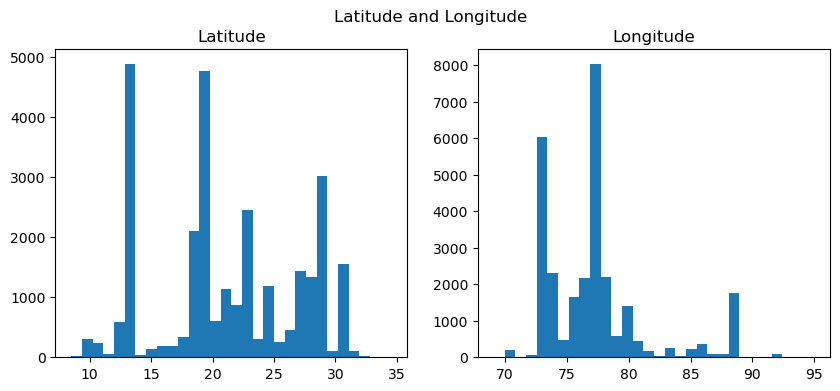

In [58]:
fig,ax=plt.subplots(1,2,figsize=(10,4))
fig.suptitle("Latitude and Longitude")

ax[0].hist(train["LATITUDE"],bins=30)
ax[0].set_title("Latitude")

ax[1].hist(train["LONGITUDE"],bins=30)
ax[1].set_title("Longitude")

plt.show()

In [59]:
train.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",77.597960,12.969910,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",76.644605,12.274538,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",77.632191,12.778033,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",77.344500,28.642300,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",88.484911,22.592200,60.5


## Feature Engineering
Create additional features that may improve the predictive power of the model.
Examples extracting the city from the address and generating derived numerical features.

In [60]:
train["CITY"] = train["ADDRESS"].str.split(",").str[-1].str.strip()
test["CITY"] = test["ADDRESS"].str.split(",").str[-1].str.strip()

In [61]:
train.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS),CITY
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",77.597960,12.969910,55.0,Bangalore
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",76.644605,12.274538,51.0,Mysore
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",77.632191,12.778033,43.0,Bangalore
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",77.344500,28.642300,62.5,Ghaziabad
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",88.484911,22.592200,60.5,Kolkata


In [62]:
train["TARGET(PRICE_IN_LACS)"].skew()

np.float64(14.470037975983304)

In [64]:
train["BHK_PER_SQ_FT"]=train["SQUARE_FT"]/train["BHK_NO."]

In [113]:
test["BHK_PER_SQ_FT"]=test["SQUARE_FT"]/test["BHK_NO."]

In [65]:
train.nlargest(10,"TARGET(PRICE_IN_LACS)")[["TARGET(PRICE_IN_LACS)","SQUARE_FT","BHK_NO.","BHK_OR_RK","BHK_PER_SQ_FT","ADDRESS"]]

,TARGET(PRICE_IN_LACS),SQUARE_FT,BHK_NO.,BHK_OR_RK,BHK_PER_SQ_FT,ADDRESS
5967,9990.0,54225.69614,2,BHK,27112.848070,"Thane West,Lalitpur"
10637,9910.0,83228.35307,3,BHK,27742.784357,"Chinchwad,Pune"
3754,9900.0,42723.97721,1,BHK,42723.977210,"Kanjur Marg (East),Maharashtra"
9799,9850.0,49689.75433,2,BHK,24844.877165,"Laxmi Nagar,Mumbai"
14519,9800.0,43773.45006,1,BHK,43773.450060,"Hiranandani Estate,Lalitpur"
4520,9760.0,139428.57140,3,BHK,46476.190467,"Sector-150 Noida,Noida"
18849,9700.0,67361.11111,2,BHK,33680.555555,"Ghodbunder Road,Mumbai"
19995,9700.0,149969.07850,3,BHK,49989.692833,"Kogilu,Bangalore"
7498,9630.0,67474.77578,2,BHK,33737.387890,"Ghodbunder Road,Maharashtra"
27517,9630.0,67474.77578,2,BHK,33737.387890,"Ghodbunder Road,Lalitpur"


In [66]:
train.nsmallest(10,"TARGET(PRICE_IN_LACS)")[["TARGET(PRICE_IN_LACS)","SQUARE_FT","BHK_NO.","BHK_OR_RK","BHK_PER_SQ_FT","ADDRESS"]]

,TARGET(PRICE_IN_LACS),SQUARE_FT,BHK_NO.,BHK_OR_RK,BHK_PER_SQ_FT,ADDRESS
14036,0.25,1923.076923,3,BHK,641.025641,"Bomikhal,Bhubaneswar"
27192,0.29,1526.315789,3,BHK,508.771930,"New Siddhapudur,Coimbatore"
20910,0.48,1500.000000,2,BHK,750.000000,"Vittal Mallya Road,Bangalore"
3882,0.85,42500.000000,10,BHK,4250.000000,"Dharga,Hosur"
8347,1.00,1333.333333,3,BHK,444.444444,"Bhayli,Vadodara"
17527,1.30,1830.985915,3,BHK,610.328638,"Sanjay nagar,Bangalore"
27895,1.50,612.244898,1,BHK,612.244898,"Balapur,Aurangabad"
19391,3.40,292.850991,1,BHK,292.850991,"Shapar,Rajkot"
18565,3.50,376.749193,1,BHK,376.749193,"Madhuban Bapudham,Ghaziabad"
28690,3.50,1000.000000,2,BHK,500.000000,"Umred Road,Lalitpur"


In [67]:
train.skew(numeric_only=True)

UNDER_CONSTRUCTION        1.670036
RERA                      0.782563
BHK_NO.                   2.203609
SQUARE_FT                18.745797
READY_TO_MOVE            -1.670036
RESALE                   -3.390486
LONGITUDE                 1.336341
LATITUDE                 -0.023171
TARGET(PRICE_IN_LACS)    14.470038
BHK_PER_SQ_FT            17.353407
dtype: float64

In [68]:
train.drop(columns='ADDRESS',inplace=True)

In [69]:
train.nunique()

POSTED_BY                    3
UNDER_CONSTRUCTION           2
RERA                         2
BHK_NO.                     16
BHK_OR_RK                    2
SQUARE_FT                19350
READY_TO_MOVE                2
RESALE                       2
LONGITUDE                 4002
LATITUDE                  4011
TARGET(PRICE_IN_LACS)     1150
CITY                       254
BHK_PER_SQ_FT            20069
dtype: int64

In [70]:
test.drop(columns='ADDRESS',inplace=True)

## EDA
Visualize relationships between important variables to better understand the dataset.
The objective is to identify trends, correlations, and possible patterns before training the models.

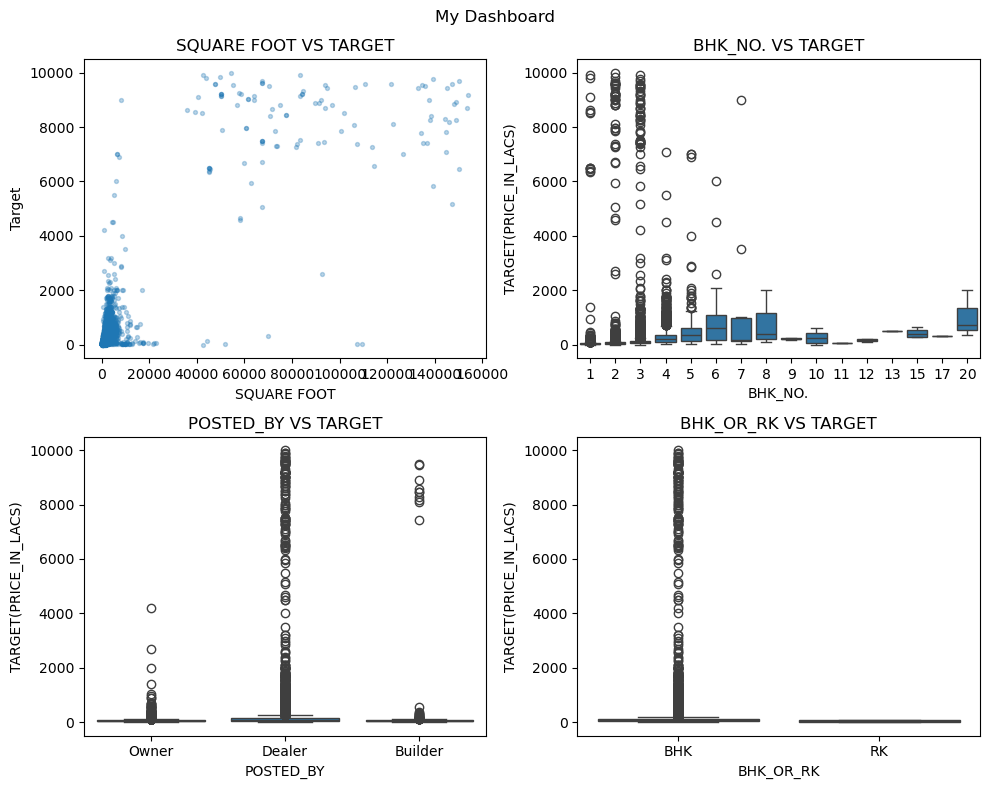

In [71]:
fig,ax=plt.subplots(2,2,figsize=(10,8))
fig.suptitle("My Dashboard")

ax[0,0].scatter(train["SQUARE_FT"],train["TARGET(PRICE_IN_LACS)"],alpha=0.3,s=8)
ax[0,0].set_xlabel("SQUARE FOOT")
ax[0,0].set_ylabel("Target")
ax[0,0].set_title("SQUARE FOOT VS TARGET")

sns.boxplot(x=train["BHK_NO."],y=train["TARGET(PRICE_IN_LACS)"],ax=ax[0,1])
ax[0,1].set_title("BHK_NO. VS TARGET")

sns.boxplot(x=train["POSTED_BY"],y=train["TARGET(PRICE_IN_LACS)"],ax=ax[1,0])
ax[1,0].set_title("POSTED_BY VS TARGET")

sns.boxplot(x=train["BHK_OR_RK"],y=train["TARGET(PRICE_IN_LACS)"],ax=ax[1,1])
ax[1,1].set_title("BHK_OR_RK VS TARGET")

plt.tight_layout()
plt.show()

Some observations appeared unusual during exploratory analysis.

However, they were not removed because there was insufficient evidence that they were incorrect records.

Since unusual property sizes or prices may represent genuine real estate listings, they were retained to avoid introducing bias into the model.

The same preprocessing steps were applied to both training and test datasets without removing observations from the test set.

## Data Preprocessing
Prepare the data for machine learning by:

- Transforming skewed variables
- Splitting the dataset
- Encoding categorical features
- Scaling numerical features

In [72]:
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV

In [73]:
from sklearn.compose import ColumnTransformer

In [74]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [75]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_squared_error,r2_score

In [76]:
from sklearn.pipeline import Pipeline

In [77]:
train["SQUARE_FT"]=np.log1p(train["SQUARE_FT"])

In [78]:
x=train.drop(columns="TARGET(PRICE_IN_LACS)")

In [79]:
y=np.log1p(train["TARGET(PRICE_IN_LACS)"])

In [80]:
x_train,x_val,y_train,y_val=train_test_split(x,y,test_size=0.2,random_state=42)

In [81]:
train.head(2)

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS),CITY,BHK_PER_SQ_FT
0,Owner,0,0,2,BHK,7.171070,1,1,77.597960,12.969910,55.0,Bangalore,650.118204
1,Dealer,0,0,2,BHK,7.151485,1,1,76.644605,12.274538,51.0,Mysore,637.500000


## Column Transformer
Use ColumnTransformer to apply different preprocessing techniques to numerical and categorical features.
This ensures the same preprocessing is applied during both training and prediction.

In [82]:
preprocessor=ColumnTransformer(transformers=[("cat",OneHotEncoder(handle_unknown='ignore',sparse_output=False),["POSTED_BY",
                                                                                                               "BHK_OR_RK",
                                                                                                               "CITY"]),
                                            ("num",StandardScaler(),["SQUARE_FT",
                                                                    "LONGITUDE",
                                                                    "LATITUDE"])
                                            ],remainder='passthrough')

In [83]:
from sklearn.neighbors import KNeighborsRegressor

In [84]:
from sklearn.linear_model import LinearRegression

In [85]:
models={"KNN":KNeighborsRegressor(),
       "Linear Regression":LinearRegression()}

In [86]:
Best_model=None
Best_cross_val=0
Best_mae=0
Best_mse=0
Best_rmse=0
Best_r2=0
result=[]

## Model training
Train and compare multiple regression algorithms to identify the best-performing model.
Evaluate each model using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score
- Cross Validation Score

In [87]:
for name, model in models.items():

    clf=Pipeline(steps=[("preprocessor",preprocessor),
                       ("model",model)])
    clf.fit(x_train,y_train)

    cross_score=cross_val_score(
        clf,
        x_train,
        y_train,
        cv=5,
        scoring="r2"
    ).mean()*100

    pred=clf.predict(x_val)
    a_pred=np.expm1(pred)
    actual=np.expm1(y_val)

    mae=mean_absolute_error(actual,a_pred)
    mse=mean_squared_error(actual,a_pred)
    rmse=np.sqrt(mse)
    r2=r2_score(actual,a_pred)
    print(f"----{name}-----")
    print(f"cross_val:{cross_score:.2f}")
    print(f"mae:{mae:.2f}")
    print(f"mse:{mse:.2f}")
    print(f"rmse:{rmse:.2f}")
    print(f"r2_score:{r2:.2f}")

    if cross_score > Best_cross_val:
        Best_cross_val=cross_score
        Best_model=clf
        Best_mae=mae
        Best_mse=mse
        Best_rmse=rmse
        Best_r2=r2
    

----KNN-----
cross_val:60.71
mae:52.74
mse:52759.96
rmse:229.70
r2_score:0.84
----Linear Regression-----
cross_val:76.89
mae:47.50
mse:58459.94
rmse:241.78
r2_score:0.82


In [88]:
result.append({"MODEL":Best_model,
"Cross val score":Best_cross_val,
"MAE":Best_mae,
"MSE":Best_mse,
"RMSE":Best_rmse,
"R2 SCORE":Best_r2})

In [89]:
from sklearn.tree import DecisionTreeRegressor

In [90]:
from sklearn.ensemble import RandomForestRegressor

In [91]:
models={"Decision Tree":DecisionTreeRegressor(random_state=42),
       "Random Forest":RandomForestRegressor(random_state=42)}

## Tree Based Preprocessing
Use ColumnTransformer to apply different preprocessing techniques to categorical feature.
This ensures the same preprocessing is applied during both training and prediction.

In [92]:
tree_preprocessor=ColumnTransformer(transformers=[("cat",OneHotEncoder(handle_unknown='ignore',sparse_output=False),["POSTED_BY",
                                                                                                               "BHK_OR_RK",
                                                                                                               "CITY"])],remainder='passthrough')

## Tree Model Training
Train and compare multiple regression algorithms to identify the best-performing model.
Evaluate each model using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score
- Cross Validation Score

In [93]:
for name, model in models.items():

    clf_tree=Pipeline(steps=[("preprocessor",tree_preprocessor),
                            ("model",model)])

    clf_tree.fit(x_train,y_train)

    cross_score=cross_val_score(
        clf_tree,
        x_train,
        y_train,
        cv=5,
        scoring="r2"
    ).mean()*100

    pred=clf_tree.predict(x_val)
    a_pred=np.expm1(pred)
    actual=np.expm1(y_val)

    mae=mean_absolute_error(actual,a_pred)
    mse=mean_squared_error(actual,a_pred)
    rmse=np.sqrt(mse)
    r2=r2_score(actual,a_pred)
    print(f"----{name}-----")
    print(f"cross_val:{cross_score:.2f}")
    print(f"mae:{mae:.2f}")
    print(f"mse:{mse:.2f}")
    print(f"rmse:{rmse:.2f}")
    print(f"r2_score:{r2:.2f}")

    if cross_score > Best_cross_val:
        Best_cross_val=cross_score
        Best_model=clf_tree
        Best_mae=mae
        Best_mse=mse
        Best_rmse=rmse
        Best_r2=r2
    

----Decision Tree-----
cross_val:74.63
mae:37.05
mse:23132.46
rmse:152.09
r2_score:0.93
----Random Forest-----
cross_val:84.91
mae:28.26
mse:15434.07
rmse:124.23
r2_score:0.95


In [94]:
result.append({"MODEL":Best_model,
"Cross val score":Best_cross_val,
"MAE":Best_mae,
"MSE":Best_mse,
"RMSE":Best_rmse,
"R2 SCORE":Best_r2})

In [95]:
compare=pd.DataFrame(result)

In [96]:
compare

,MODEL,Cross val score,MAE,MSE,RMSE,R2 SCORE
0,"(ColumnTransformer(remainder='passthrough',\n ...",76.886142,47.501893,58459.940672,241.784906,0.823753
1,"(ColumnTransformer(remainder='passthrough',\n ...",84.913227,28.261887,15434.065867,124.233916,0.953469


Optimize the best-performing model using GridSearchCV to improve predictive performance.

In [97]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 20]
}

In [98]:
grid_search=GridSearchCV(estimator=clf_tree,
                        param_grid=param_grid,
                        cv=5,
                        scoring="r2",
                        n_jobs=-1)

In [99]:
grid_search.fit(x_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 20], 'model__n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...)]"


In [100]:
print(grid_search.best_params_)

{'model__max_depth': 20, 'model__n_estimators': 200}


In [104]:
print(grid_search.best_score_)

0.8502159593852232


In [105]:
pred=grid_search.predict(x_val)

In [107]:
a_pred=np.expm1(pred)

In [108]:
actual=np.expm1(y_val)

In [111]:
print(f"Mae:{mean_absolute_error(actual,a_pred)}")
print(f"Mse:{mean_squared_error(actual,a_pred)}")
print(f"rmse:{np.sqrt(mse)}")
print(f"r2:{r2_score(actual,a_pred)}")

Mae:28.248481295688208
Mse:15690.03421706398
rmse:124.23391592823846
r2:0.9526972608530342


## Final Prediction
Generating predictions on the unseen test dataset using the optimized model and create the submission file.

In [114]:
test_pred=grid_search.predict(test)

In [116]:
actual_test_pred=np.expm1(test_pred)

In [117]:
submission=pd.DataFrame({"TARGET(PRICE_IN_LACS)":actual_test_pred})

In [118]:
submission.to_csv("submission.csv",index=False)

## Final Results

Multiple regression algorithms were compared.
Random Forest Regressor produced the best overall performance after hyperparameter tuning.

Final Results

- Cross Validation: 85%
- MAE: 28.25
- RMSE: 124.23
- R² Score: 0.953

The tuned Random Forest model was selected as the final model for prediction.

## Future Improvements

Although the model achieved strong performance, several improvements can be explored in future work:

- Experiment with XGBoost, LightGBM, and CatBoost.
- Perform more detailed feature engineering.
- Explore advanced outlier detection techniques.
- Tune additional hyperparameters using RandomizedSearchCV or Bayesian Optimization.
- Investigate feature importance and model explainability using SHAP.